## 暂退法
当面对更多的特征而样本不足时，线性模型往往会过拟合。 相反，当给出更多样本而不是特征，通常线性模型不会过拟合。 不幸的是，线性模型泛化的可靠性是有代价的。 简单地说，线性模型没有考虑到特征之间的交互作用。 对于每个特征，线性模型必须指定正的或负的权重，而忽略其他特征。
泛化性和灵活性之间的这种基本权衡被描述为偏差-方差权衡（bias-variance tradeoff）。 线性模型有很高的偏差：它们只能表示一小类函数。 然而，这些模型的方差很低：它们在不同的随机数据样本上可以得出相似的结果。
1995年，克里斯托弗·毕晓普证明了 具有输入噪声的训练等价于Tikhonov正则化 (Bishop, 1995)。 这项工作用数学证实了“要求函数光滑”和“要求函数对输入的随机噪声具有适应性”之间的联系。
然后在2014年，斯里瓦斯塔瓦等人 (Srivastava et al., 2014) 就如何将毕晓普的想法应用于网络的内部层提出了一个想法： 在训练过程中，他们建议在计算后续层之前向网络的每一层注入噪声。 因为当训练一个有多层的深层网络时，注入噪声只会在输入-输出映射上增强平滑性。
这个想法被称为*暂退法（dropout）*。 暂退法在前向传播过程中，计算每一内部层的同时注入噪声，这已经成为训练神经网络的常用技术。 这种方法之所以被称为暂退法，因为我们从表面上看是在训练过程中丢弃（drop out）一些神经元。 在整个训练过程的每一次迭代中，标准暂退法包括在计算下一层之前将当前层中的一些节点置零。
那么关键的挑战就是如何注入这种噪声。 一种想法是以一种*无偏向（unbiased）*的方式注入噪声。 这样在固定住其他层时，每一层的期望值等于没有噪音时的值。
### 从0开始实现
要实现单层的暂退法函数， 我们从均匀分布$U[0,1]$中抽取样本，样本数与这层神经网络的维度一致。 然后我们保留那些对应样本大于p的节点，把剩下的丢弃。在下面的代码中，我们实现 dropout_layer 函数， 该函数以dropout的概率丢弃张量输入X中的元素， 如上所述重新缩放剩余部分：将剩余部分除以1.0-dropout。

In [2]:
import torch
from torch import nn
from d2l import torch as d2l
import trainch3
def dropout_layer(X,dropout):
    assert 0<= dropout <= 1
    # 在本情况下，所有元素都被丢弃
    if dropout == 1:
        return torch.zeros_like(X)
    # 在本情况中，所有元素都被保留
    if dropout == 0:
        return X
    mask = (torch.rand(X.shape)>dropout).float() # 生成一个与X形状相同的张量与dropout进行比较判断哪些该保留，转换成浮点是为了方便后续运算，防止类型不匹配
    return mask * X / (1.0 - dropout)

In [3]:
# 输入X通过暂退法操作，暂退概率分别为0、0.5、和1
X = torch.arange(16,dtype=torch.float32).reshape((2,8))
print(X)
print(dropout_layer(X,0.))
print(dropout_layer(X,0.5))
print(dropout_layer(X,1.))


tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  0.,  4.,  6.,  0., 10., 12.,  0.],
        [ 0., 18., 20., 22.,  0., 26., 28., 30.]])
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


#### 定义模型参数
同样，我们使用 3.5节中引入的Fashion-MNIST数据集。 我们定义具有两个隐藏层的多层感知机，每个隐藏层包含256个单元。


In [4]:
num_inputs,num_outputs,num_hiddens1,num_hiddens2 = 784,10,256,256

#### 定义模型
我们可以将暂退法应用于每个隐藏层的输出（在激活函数之后）， 并且可以为每一层分别设置暂退概率： 常见的技巧是在靠近输入层的地方设置较低的暂退概率。 下面的模型将第一个和第二个隐藏层的暂退概率分别设置为0.2和0.5， 并且暂退法只在训练期间有效。

In [5]:
dropout1,dropout2 = 0.2,0.5

class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2, is_training = True):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        # 只有在训练模型时才使用dropout
        if self.training == True:
            # 在第一个全连接层之后添加一个dropout层
            H1 = dropout_layer(H1, dropout1)
        H2 = self.relu(self.lin2(H1))
        if self.training == True:
            # 在第二个全连接层之后添加一个dropout层
            H2 = dropout_layer(H2, dropout2)
        out = self.lin3(H2)
        return out
    
net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)

(0.3397040547053019, 0.8747833333333334)


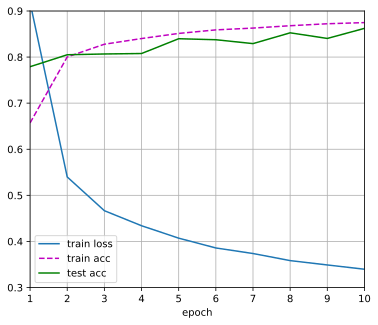

In [6]:
# 训练和测试
num_epochs, lr, batch_size = 10, 0.5, 256
loss = nn.CrossEntropyLoss(reduction='none')
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
trainch3.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

#### 简洁实现
对于深度学习框架的高级API，我们只需在每个全连接层之后添加一个Dropout层， 将暂退概率作为唯一的参数传递给它的构造函数。 在训练时，Dropout层将根据指定的暂退概率随机丢弃上一层的输出（相当于下一层的输入）。 在测试时，Dropout层仅传递数据。

(0.3476268583615621, 0.87245)


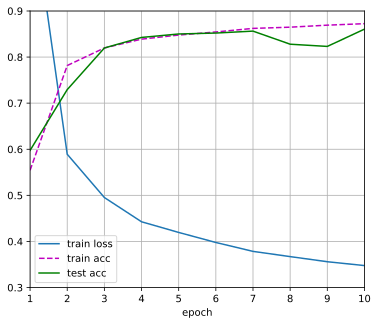

: 

In [7]:
net = nn.Sequential(nn.Flatten(),
        nn.Linear(784, 256),
        nn.ReLU(),
        # 在第一个全连接层之后添加一个dropout层
        nn.Dropout(dropout1),
        nn.Linear(256, 256),
        nn.ReLU(),
        # 在第二个全连接层之后添加一个dropout层
        nn.Dropout(dropout2),
        nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);

trainer = torch.optim.SGD(net.parameters(), lr=lr)
trainch3.train_ch3(net,train_iter,test_iter,loss,num_epochs,trainer)